In [14]:
import numpy as np
from pathlib import Path
import pandas as pd
import akshare as ak
import matplotlib.pyplot as plt
import sys

project_root = Path.cwd().parent
src_path = project_root / "src"
sys.path.append(str(src_path))

%load_ext autoreload
%autoreload 2

from backtest import ma_cross_backtest, backtest_plot_drawdown, backtest_plot_nav, backtest_plot_sbpoints, calculate_performance, calculate_buy_and_sell

RAW_DIR = project_root / "data" / "raw"
PROCESSED_DIR = project_root / "data" / "processed"
REPORT_DIR = project_root / "reports"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


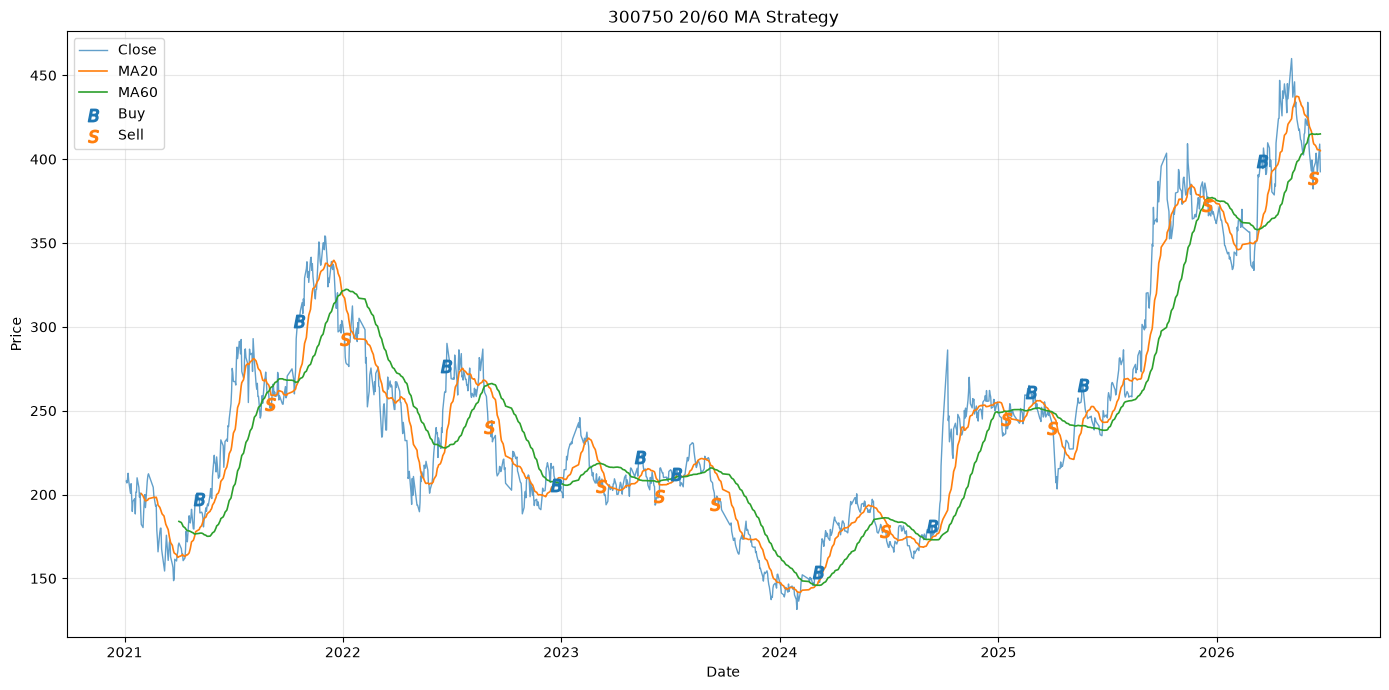

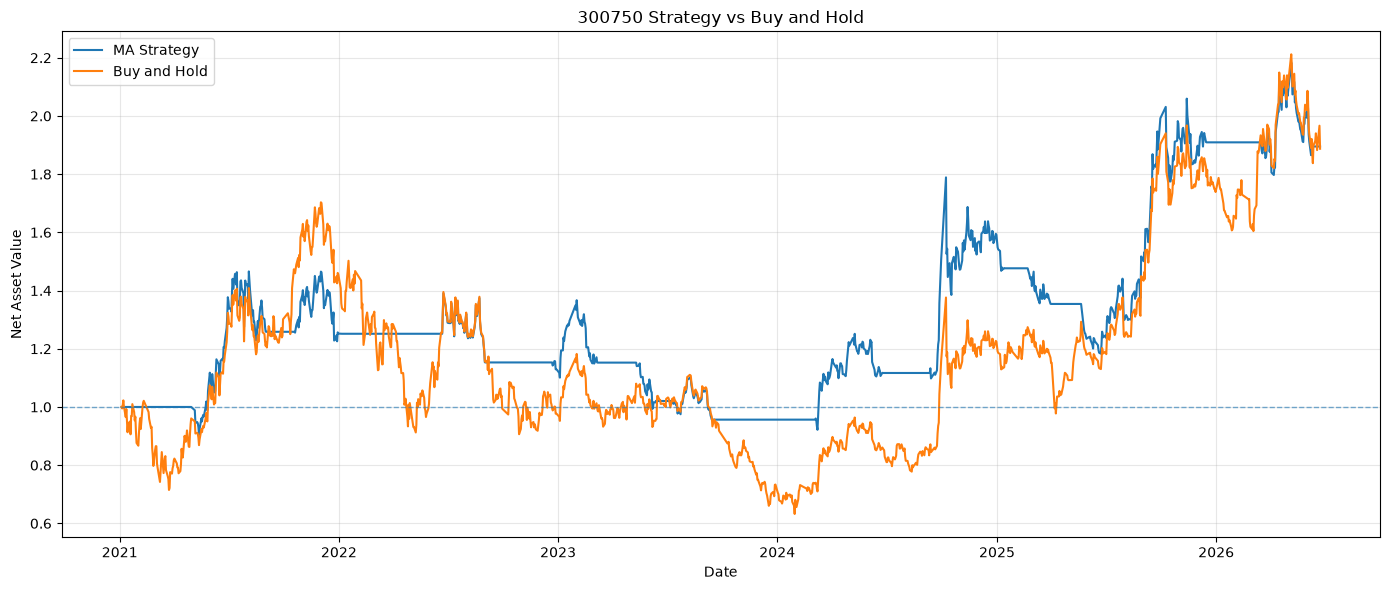

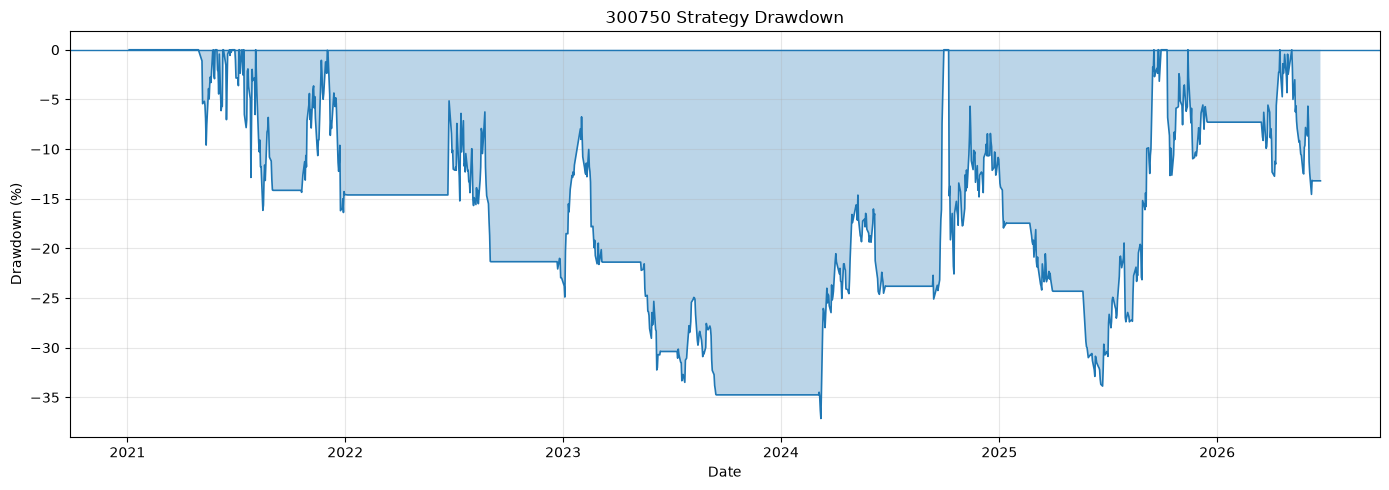

In [3]:
symbol = "300750"
df = pd.read_csv(f"{RAW_DIR}\{symbol}_qfq_daily.csv")
result = ma_cross_backtest(df)
backtest_plot_sbpoints(result)
backtest_plot_nav(result)
backtest_plot_drawdown(result)

In [5]:
# 要把两种策略在同一起跑线上进行比较，因此要排除均线没有形成时的数据，此时只有单次buy的数据但没有均线策略数据
evaluation_mask = (
    result["slow_ma"]
    .shift(1)
    .notna()
)

evaluation_data = (
    result.loc[evaluation_mask]
    .copy()
    .reset_index(drop=True)
)

print(
    "绩效评价开始日期：",
    evaluation_data["date"].iloc[0],
)

print(
    "绩效评价结束日期：",
    evaluation_data["date"].iloc[-1],
)

print(
    "评价交易日数量：",
    len(evaluation_data),
)

evaluation_data["strategy_nav_eval"] = (
    1 + evaluation_data["strategy_return"]
).cumprod()

evaluation_data["benchmark_nav_eval"] = (
    1 + evaluation_data["asset_return"]
).cumprod()


绩效评价开始日期： 2021-04-06 00:00:00
绩效评价结束日期： 2026-06-23 00:00:00
评价交易日数量： 1263


In [6]:
strategy_metrics = calculate_performance(
    returns=evaluation_data["strategy_return"],
    annual_risk_free_rate=0.0,
    trading_days=252,
)

benchmark_metrics = calculate_performance(
    returns=evaluation_data["asset_return"],
    annual_risk_free_rate=0.0,
    trading_days=252,
)

performance_comparison = pd.DataFrame(
    {
        "MA Strategy": strategy_metrics,
        "Buy and Hold": benchmark_metrics,
    }
).T

# 把浮点数转成两位小数的百分数
performance_display = (
    performance_comparison.copy()
)

percentage_cols = [
    "cumulative_return",
    "annual_return",
    "annual_volatility",
    "max_drawdown",
]

for col in percentage_cols:
    performance_display[col] = (
        performance_display[col]
        .map(lambda value: f"{value:.2%}")
    )

ratio_cols = [
    "sharpe_ratio",
    "calmar_ratio",
]

for col in ratio_cols:
    performance_display[col] = (
        performance_display[col]
        .map(
            lambda value: (
                "NaN"
                if pd.isna(value)
                else f"{value:.3f}"
            )
        )
    )

# 转成中文，更易阅读
column_name_map = {
    "cumulative_return": "累计收益率",
    "annual_return": "年化收益率",
    "annual_volatility": "年化波动率",
    "sharpe_ratio": "夏普比率",
    "max_drawdown": "最大回撤",
    "calmar_ratio": "卡玛比率",
}

performance_display_cn = (
    performance_display
    .rename(columns=column_name_map)
    .rename(
        index={
            "MA Strategy": "20/60均线策略",
            "Buy and Hold": "买入持有",
        }
    )
)

display(performance_display_cn)

,累计收益率,年化收益率,年化波动率,夏普比率,最大回撤,卡玛比率
20/60均线策略,89.51%,13.60%,31.66%,0.559,-37.13%,0.366
买入持有,129.44%,18.02%,42.26%,0.601,-62.88%,0.287


In [7]:
# 计算买卖次数
buy_and_sell = pd.Series(calculate_buy_and_sell(evaluation_data))
display(buy_and_sell)

评价交易日数量     1263.000000
持仓比例           0.540776
买入次数          11.000000
卖出次数          11.000000
总交易次数         22.000000
交易成本简单加总       0.011000
dtype: float64

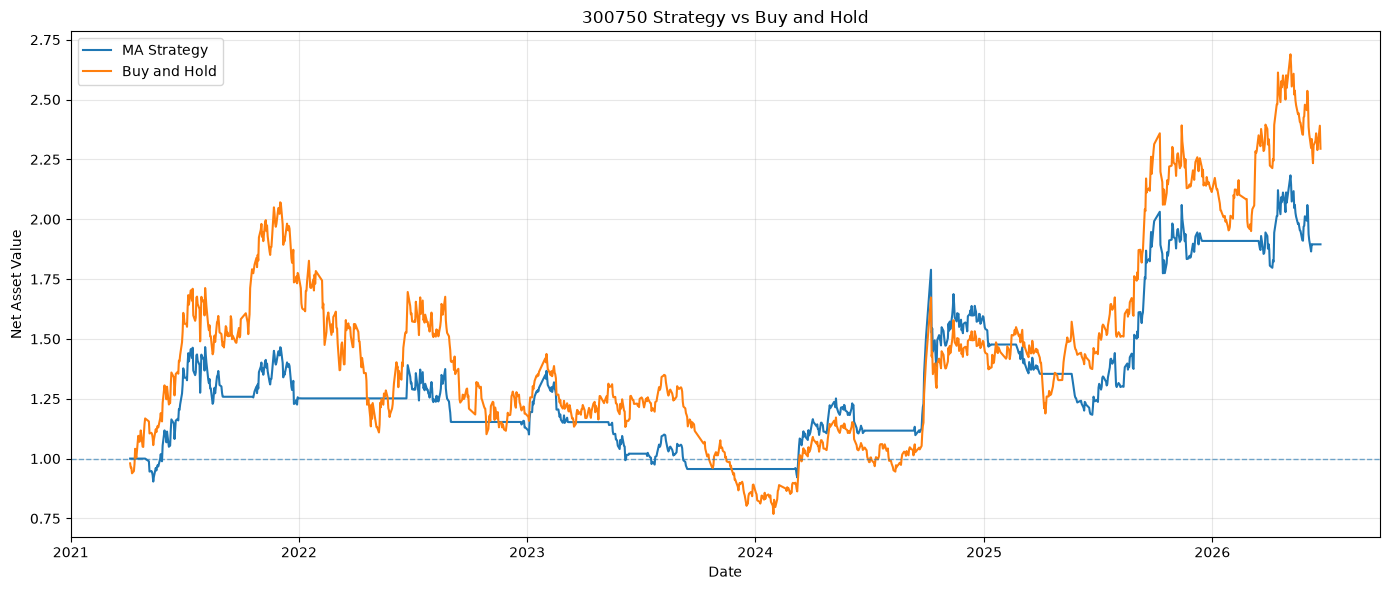

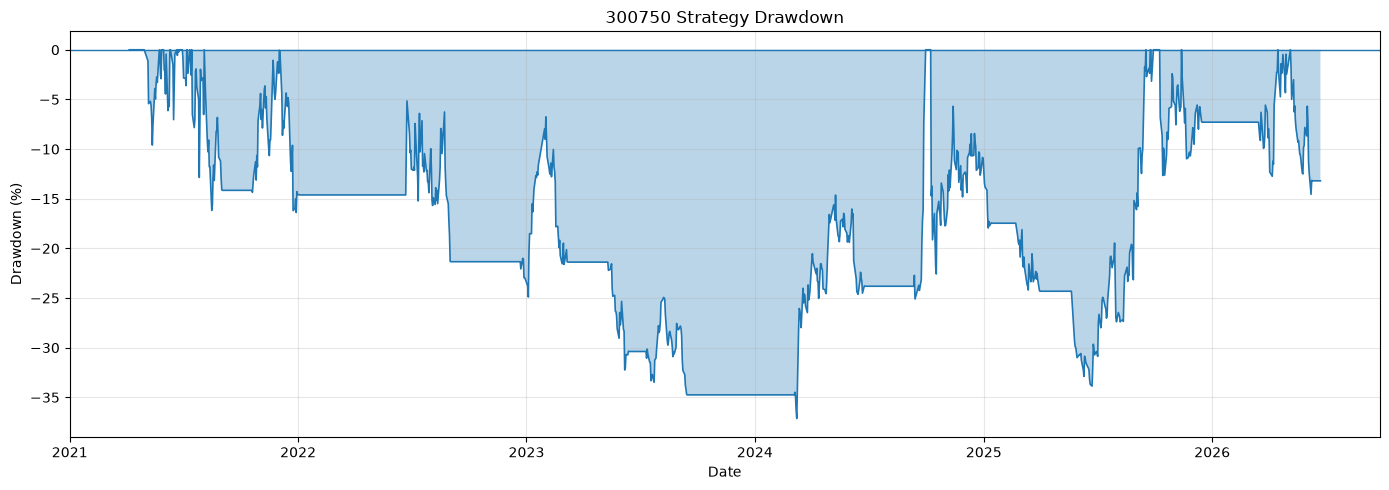

In [15]:
# 绘制新的收益图和回撤图
backtest_plot_nav(evaluation_data, strategy_nav="strategy_nav_eval", benchmark_nav="benchmark_nav_eval")
backtest_plot_drawdown(evaluation_data)